# EDMD with Net Wrench Inputs

Train an EDMD/Koopman model where the control inputs are the 6D centroidal net wrench (Fx,Fy,Fz,Mx,My,Mz). The notebook mirrors the geometric basis in `edmd_runner.py` and evaluates on validation windows.

In [114]:
# ---- Config ----
from pathlib import Path

EXP_FILE = Path("../../datasets/go1/flat_terrain/experiment3.h5")

# EDMD hyperparameters
P_MAX   = 5            # polynomial degree for geometric lift
L2_REG  = 1e-6         # ridge on G2 for stability
VAL_FR  = 0.2          # fraction of data for validation (by trajectory)
H       = 20           # rollout horizon for open-loop eval
SEED    = 1274         # RNG seed for splits and window sampling
N_WINDOWS = 20         # number of random validation windows to score

# Dataset preprocessing
RAW_DT      = 0.002    # base simulation dt before downsample (s)
DOWNSAMPLE  = 10       # keep every k-th sample (1 = no downsample)
NORMALIZE   = None     # or "minmax" to scale to [-1,1]
MASK_INPUTS = True     # zero swing-leg forces before wrench computation
TRIM_HEAD_SEC = 0.2    # drop first seconds of each episode (startup spike)

print("[config] exp file:", EXP_FILE.resolve())
print(f"[config] p_max={P_MAX}, l2_reg={L2_REG}, val_frac={VAL_FR}, H={H}, seed={SEED}")
print(f"[dataset] dt={RAW_DT}s, downsample={DOWNSAMPLE}, normalize={NORMALIZE}, mask_inputs={MASK_INPUTS}, trim_head_sec={TRIM_HEAD_SEC}")

[config] exp file: /home/sriramk/quad_koopman_mpc/datasets/go1/flat_terrain/experiment3.h5
[config] p_max=5, l2_reg=1e-06, val_frac=0.2, H=20, seed=1274
[dataset] dt=0.002s, downsample=10, normalize=None, mask_inputs=True, trim_head_sec=0.2


In [115]:
# ---- Imports ----
import numpy as np
import matplotlib.pyplot as plt

from data_loader import QuadrupedEDMDDataset
from h5_reader import H5Reader
from edmd_runner import (
    edmd_with_inputs,
    rollout_open_loop_geom,
    lift_1d, lift_row,
    decode_state_from_geom_phi,
    train_val_split,
)
from eval_nstep import eval_nstep_window

rng = np.random.default_rng(SEED)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (6.0, 4.0)

In [116]:
# ---- Build X0, X1, U0 using net wrench inputs ----
assert EXP_FILE.exists(), f"Dataset file not found: {EXP_FILE}"

reader = H5Reader(file_path=str(EXP_FILE), lazy=True)

ds = QuadrupedEDMDDataset(
    dataset=reader,
    downsample=DOWNSAMPLE,
    pos_zero_start=True,
    normalize=NORMALIZE,
    input_mode="wrench",            # <-- key change: centroidal net wrench (6D)
    mask_inputs_by_contact=MASK_INPUTS,
).build()

# Optionally trim the first TRIM_HEAD_SEC seconds per episode to remove startup spikes
trim_steps = 0
if TRIM_HEAD_SEC and TRIM_HEAD_SEC > 0:
    trim_steps = int(round(TRIM_HEAD_SEC / (RAW_DT * max(1, DOWNSAMPLE))))
    trim_steps = max(trim_steps, 0)

    def trim_head_transitions(ds_obj, n_trim):
        if n_trim <= 0:
            return ds_obj
        X0, X1, U0 = ds_obj.X0, ds_obj.X1, ds_obj.U0
        contact, feet, com = ds_obj.contact0, ds_obj.feet0, ds_obj.com0
        traj_ids = ds_obj.traj_ids

        X0_list = []; X1_list = []; U0_list = []
        contact_list = []; feet_list = []; com_list = []
        traj_list = []
        bounds_new = []
        cursor = 0

        for ep_idx, (s_ep, e_ep) in enumerate(ds_obj.episode_bounds):
            keep_start = min(e_ep, s_ep + n_trim)
            if keep_start >= e_ep:
                continue
            sl = slice(keep_start, e_ep)
            X0_list.append(X0[sl]); X1_list.append(X1[sl]); U0_list.append(U0[sl])
            if contact is not None:
                contact_list.append(contact[sl])
            if feet is not None:
                feet_list.append(feet[sl])
            if com is not None:
                com_list.append(com[sl])
            if traj_ids is not None:
                traj_list.append(np.full((e_ep - keep_start,), ep_idx, dtype=np.int32))
            bounds_new.append((cursor, cursor + (e_ep - keep_start)))
            cursor += (e_ep - keep_start)

        if not X0_list:
            raise RuntimeError("All transitions were trimmed away; reduce TRIM_HEAD_SEC.")

        ds_obj.X0 = np.concatenate(X0_list, axis=0)
        ds_obj.X1 = np.concatenate(X1_list, axis=0)
        ds_obj.U0 = np.concatenate(U0_list, axis=0)
        ds_obj.episode_bounds = bounds_new
        if traj_list:
            ds_obj.traj_ids = np.concatenate(traj_list, axis=0)
        if contact_list:
            ds_obj.contact0 = np.concatenate(contact_list, axis=0)
        if feet_list:
            ds_obj.feet0 = np.concatenate(feet_list, axis=0)
        if com_list:
            ds_obj.com0 = np.concatenate(com_list, axis=0)
        return ds_obj

    ds = trim_head_transitions(ds, trim_steps)
    print(f"[trim] dropped first {trim_steps} transitions (~{TRIM_HEAD_SEC:.3f}s) per episode")

X0, X1, U0 = ds.X0, ds.X1, ds.U0
CONTACT    = ds.contact0   # (N,4) or None
FEET_POS   = ds.feet0      # (N,4,3) or None
COM_POS    = ds.com0       # (N,3) or fallback to base_pos

print(f"X0 shape: {X0.shape}  |  X1 shape: {X1.shape}  |  U0 shape: {U0.shape}  | mode=wrench")
print("Extras available:",
      f"contact={CONTACT is not None}, feet_pos={FEET_POS is not None}, com={COM_POS is not None}")

assert U0.shape[1] == 6, "Wrench mode expects U0 ∈ R^{N×6}."
print(f"Net wrench stats: Fx mean={U0[:,0].mean():.3f}, Fy mean={U0[:,1].mean():.3f}, Fz mean={U0[:,2].mean():.3f}")


[trim] dropped first 10 transitions (~0.200s) per episode
X0 shape: (298900, 12)  |  X1 shape: (298900, 12)  |  U0 shape: (298900, 6)  | mode=wrench
Extras available: contact=True, feet_pos=True, com=True
Net wrench stats: Fx mean=0.030, Fy mean=-0.011, Fz mean=125.132


In [117]:
# ---- Split by trajectory, fit EDMD ----
splits = ds.train_val_split_by_traj(val_frac=VAL_FR, seed=SEED)
tr, va = splits["train"], splits["val"]
print(f"[split] train N={tr['X0'].shape[0]}  |  val N={va['X0'].shape[0]}")

lift_fn = lambda x: lift_1d(x, P_MAX)
A, B = edmd_with_inputs(tr["X0"], tr["X1"], tr["U0"], lift_fn=lift_fn, l2_reg=L2_REG)

nphi = lift_fn(tr["X0"][0]).shape[0]
nu   = tr["U0"].shape[1] if tr["U0"].ndim == 2 else 0
print(f"[model] n_phi={nphi}  |  nu={nu}  |  p_max={P_MAX}  |  l2_reg={L2_REG}")

[split] train N=239120  |  val N=59780
[model] n_phi=69  |  nu=6  |  p_max=5  |  l2_reg=1e-06


In [118]:
# ---- Save model + quick spectral check ----
save_dir = Path("saved_models_koopman")
save_dir.mkdir(parents=True, exist_ok=True)
model_path = save_dir / "wrench_model.npz"
np.savez(model_path, A=A, B=B, meta=dict(p_max=P_MAX, l2_reg=L2_REG, input_mode="wrench"))
print("Model saved to:", model_path.resolve())

eigA = np.linalg.eigvals(A)
rhoA = np.abs(eigA).max()
print(f"Spectral radius ρ(A) = {rhoA:.6f}  | stable if < 1 for discrete time")

Model saved to: /home/sriramk/quad_koopman_mpc/simulation/edmd/saved_models_koopman/wrench_model.npz
Spectral radius ρ(A) = 1.000143  | stable if < 1 for discrete time


In [119]:
# ---- RMSE helper (matches edmd_runner) ----
def _wrap_to_pi(a: np.ndarray) -> np.ndarray:
    return (a + np.pi) % (2*np.pi) - np.pi

def compute_rmse(X_true: np.ndarray, X_pred: np.ndarray, wrap_euler: bool = True):
    '''
    Per-state RMSE and overall RMSE. Wrap Euler residuals when nx==12.
    '''
    X_true = np.asarray(X_true, float)
    X_pred = np.asarray(X_pred, float)
    assert X_true.shape == X_pred.shape, f"shape mismatch: {X_true.shape} vs {X_pred.shape}"

    err = X_pred - X_true
    if wrap_euler and X_true.shape[1] == 12:
        err[:, 3:6] = _wrap_to_pi(err[:, 3:6])

    rmse_per_state = np.sqrt(np.mean(err**2, axis=0))
    overall_rmse   = float(np.sqrt(np.mean(rmse_per_state**2)))
    return rmse_per_state, overall_rmse

In [120]:
# ---- Build validation windows confined to episodes ----
val_mask = splits["val_mask"]
idx_val = np.flatnonzero(val_mask)
assert idx_val.size >= H, f"Validation region shorter than H={H}; adjust val_frac or H."
val_start = int(idx_val.min())
val_end   = int(idx_val.max())

# Episode transition slices (start, length) over flattened transitions

def episode_transition_slices(ds):
    return [(int(s), int(e - s)) for (s, e) in ds.episode_bounds]

eligible = []
for e_idx, (s_ep, len_ep) in enumerate(episode_transition_slices(ds)):
    if len_ep <= 0:
        continue
    seg_start = max(s_ep, val_start)
    seg_end   = min(s_ep + len_ep, val_end + 1)  # exclusive
    seg_len   = seg_end - seg_start
    if seg_len >= H:
        eligible.append(dict(
            episode_idx=e_idx,
            seg_start=int(seg_start),
            seg_len=int(seg_len),
            ep_len=int(len_ep),
            ep_start=int(s_ep),
        ))

assert len(eligible) > 0, "No validation episode long enough for H-step window."

if len(eligible) >= N_WINDOWS:
    chosen = rng.choice(len(eligible), size=N_WINDOWS, replace=False)
else:
    chosen = rng.choice(len(eligible), size=N_WINDOWS, replace=True)

windows = []
for ci in chosen:
    seg = eligible[int(ci)]
    max_offset = seg["seg_len"] - H
    offset = int(rng.integers(0, max_offset + 1))
    start_idx = seg["seg_start"] + offset
    windows.append(dict(
        episode_idx=seg["episode_idx"],
        start_idx=int(start_idx),
        offset=int(offset),
        H_eff=int(H),
        ep_len=seg["ep_len"],
    ))

print(f"[windows] sampled {len(windows)} validation windows (len={H}) from {len(eligible)} eligible episodes")

[windows] sampled 20 validation windows (len=20) from 100 eligible episodes


In [121]:
# ---- Evaluate windows with eval_nstep_window ----
per_window_rmse = []
overall_list    = []
used_rows       = []

for w in windows:
    res = eval_nstep_window(
        A, B, lift_fn,
        ds, splits,
        X0, X1, U0,
        P_MAX, w["H_eff"],
        start_index=w["start_idx"],
        degrees=False,
    )
    X_true_w = res["X_true_plot"]
    X_pred_w = res["X_pred_plot"]
    labels_w = res.get("labels", None)

    rmse_s, overall = compute_rmse(X_true_w, X_pred_w)
    per_window_rmse.append(rmse_s)
    overall_list.append(overall)

    used_rows.append({
        "episode_idx": w["episode_idx"],
        "start_idx": w["start_idx"],
        "start_offset_in_episode": w["offset"],
        "H": w["H_eff"],
        "episode_len": w["ep_len"],
        "overall_rmse": float(overall),
    })

per_window_rmse = np.vstack(per_window_rmse)
overall_arr     = np.asarray(overall_list)

mean_rmse_s = per_window_rmse.mean(axis=0)
std_rmse_s  = per_window_rmse.std(axis=0, ddof=0)
mean_overall = float(overall_arr.mean())
std_overall  = float(overall_arr.std(ddof=0))

print(f"[eval/val] overall RMSE = {mean_overall:.6f} ± {std_overall:.6f} across {len(windows)} windows")
labels_eval = labels_w if labels_w is not None else [f"x{i}" for i in range(len(mean_rmse_s))]

[eval/val] overall RMSE = 0.032838 ± 0.007201 across 20 windows


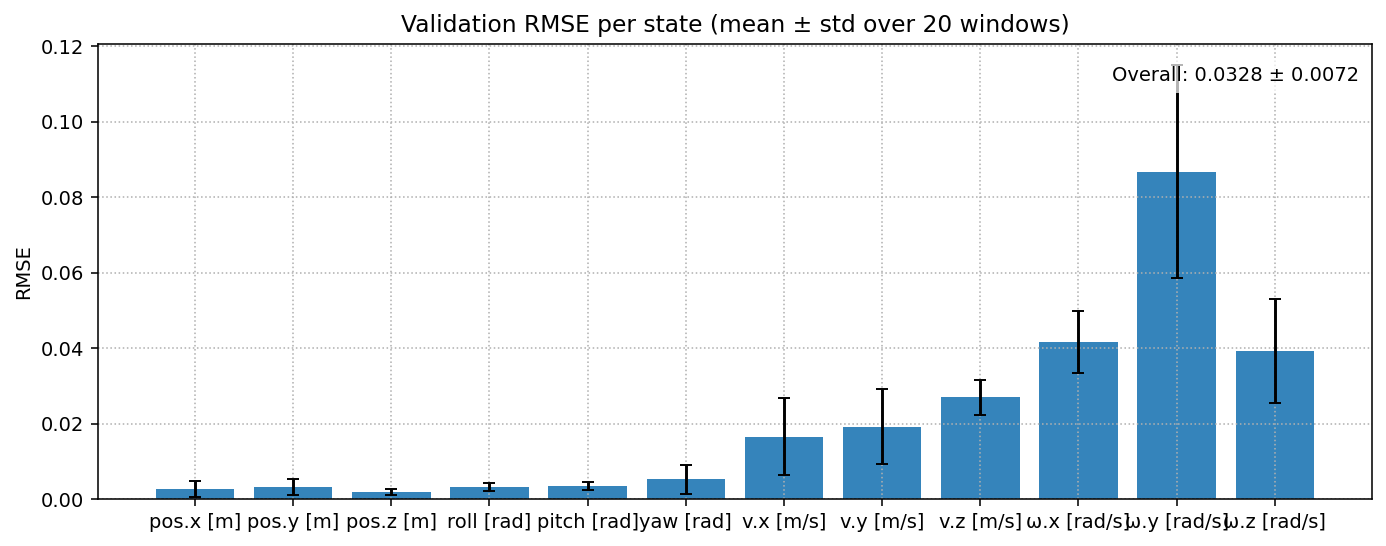

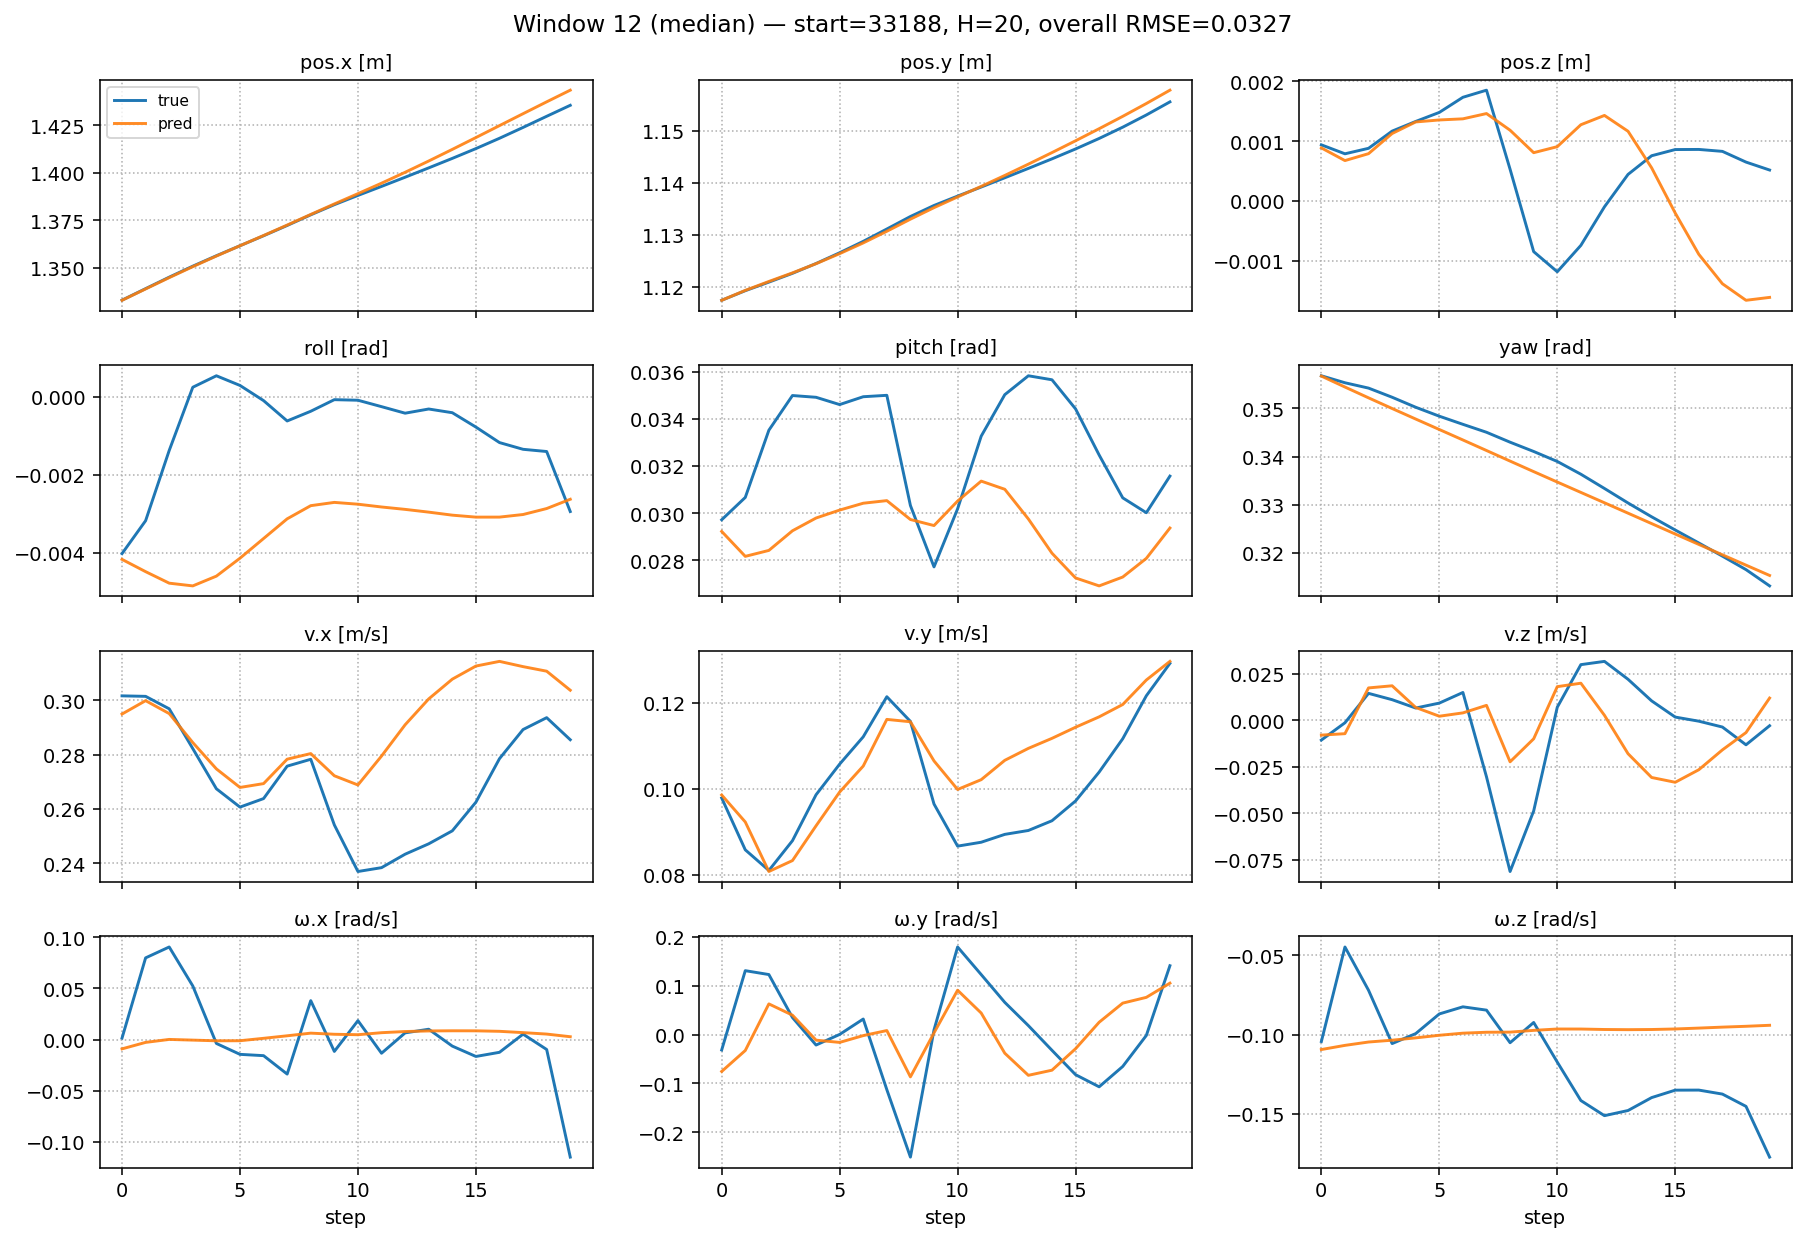

In [122]:
# ---- Visualization: per-state RMSE + one window ----
import matplotlib.pyplot as plt

labels_use = labels_eval[:len(mean_rmse_s)]

# Chart A: per-state RMSE
figA, axA = plt.subplots(figsize=(10, 4))
idx = np.arange(len(mean_rmse_s))
axA.bar(idx, mean_rmse_s, yerr=std_rmse_s, capsize=3, alpha=0.9)
axA.set_xticks(idx)
axA.set_xticklabels(labels_use, rotation=0)
axA.set_ylabel("RMSE")
axA.set_title(f"Validation RMSE per state (mean ± std over {len(windows)} windows)")
axA.grid(True, linestyle=":")
axA.text(0.99, 0.95, f"Overall: {mean_overall:.4f} ± {std_overall:.4f}",
         transform=axA.transAxes, ha="right", va="top",
         bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
plt.tight_layout()
plt.show()

# Pick best/median/worst window
order = np.argsort(overall_arr)
idx_best  = int(order[0])
idx_med   = int(order[len(order)//2])
idx_worst = int(order[-1])
WHICH = "median"   # "best" "median" / "worst"
idx_pick = {"best": idx_best, "median": idx_med, "worst": idx_worst}[WHICH]
w = windows[idx_pick]
Hwin = int(w["H_eff"])

res = eval_nstep_window(
    A, B, lift_fn,
    ds, splits,
    X0, X1, U0,
    P_MAX, Hwin,
    start_index=w["start_idx"],
    degrees=False,
)
X_true_w = res["X_true_plot"]
X_pred_w = res["X_pred_plot"]
labels_w = res.get("labels", labels_use)

# Wrap Euler for plotting only
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def wrap_states_for_plot(X):
    Xp = X.copy()
    if Xp.shape[1] >= 6:
        Xp[:, 3:6] = wrap_pi(Xp[:, 3:6])
    return Xp

Xt = wrap_states_for_plot(X_true_w)
Xp = wrap_states_for_plot(X_pred_w)
t = np.arange(Hwin)

figB, axes = plt.subplots(4, 3, figsize=(13, 9), sharex=True)
axes = axes.ravel()
nx = Xt.shape[1]
for i in range(min(12, nx)):
    ax = axes[i]
    ax.plot(t, Xt[:, i], label="true")
    ax.plot(t, Xp[:, i], label="pred", alpha=0.9)
    ttl = labels_w[i] if i < len(labels_w) else f"x{i}"
    ax.set_title(ttl, fontsize=10)
    ax.grid(True, linestyle=":")
for j in range(min(12, nx), 12):
    axes[j].axis("off")
axes[-3].set_xlabel("step"); axes[-2].set_xlabel("step"); axes[-1].set_xlabel("step")
axes[0].legend(fontsize=8, loc="best")
figB.suptitle(f"Window {idx_pick} ({WHICH}) — start={w['start_idx']}, H={Hwin}, overall RMSE={overall_arr[idx_pick]:.4f}")
plt.tight_layout()
plt.show()